In [1]:
import requests
import zipfile
from pathlib import Path

In [2]:



data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"


if image_path.is_dir():
    print(f"{image_path} is already exsits!")
else:
    print(f"{image_path} creating...")
    image_path.mkdir(parents=True,exist_ok=True)
    
zip_file_path = data_path/"pizza_steak_sushi.zip"
#with open(zip_file_path,"wb") as f:
   # request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/data/pizza_steak_sushi.zip")
   # print(f"Downloading data")
    # f.write(request.content)

#unzip
#
#with zipfile.ZipFile(zip_file_path,"r") as zip_ref:
#    print("unziping")
#    zip_ref.extractall(image_path)

data\pizza_steak_sushi is already exsits!


In [3]:
import os
def walk_through_dir(dir_path):
    """ walks through dir_path returning its contents

    Args:
        dir_path (_type_): _description_
    """
    
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} dirs and {len(filenames)} images in {dirpath}")

In [4]:
walk_through_dir(image_path)

There are 2 dirs and 0 images in data\pizza_steak_sushi
There are 3 dirs and 0 images in data\pizza_steak_sushi\test
There are 0 dirs and 25 images in data\pizza_steak_sushi\test\pizza
There are 0 dirs and 19 images in data\pizza_steak_sushi\test\steak
There are 0 dirs and 31 images in data\pizza_steak_sushi\test\sushi
There are 3 dirs and 0 images in data\pizza_steak_sushi\train
There are 0 dirs and 78 images in data\pizza_steak_sushi\train\pizza
There are 0 dirs and 75 images in data\pizza_steak_sushi\train\steak
There are 0 dirs and 72 images in data\pizza_steak_sushi\train\sushi


In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"


data\pizza_steak_sushi\test\sushi\2394442.jpg sushi


torch.Size([408, 512, 3])

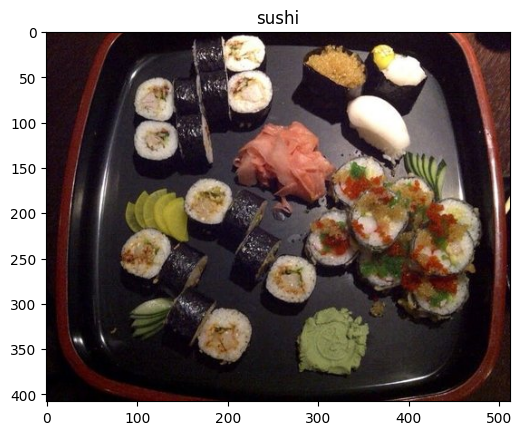

In [6]:
import random
from PIL import Image
from matplotlib import pyplot as plt
import torch
random.seed(42)

images_list = list(image_path.glob("**/*/*.jpg"))

random_image_path = random.choice(images_list)
random_image_class = random_image_path.parent.stem
print(random_image_path,random_image_class)


random_img = Image.open(random_image_path)

plt.imshow(random_img)
plt.title(random_image_class)
import numpy as np


t =torch.tensor(np.asarray(random_img))
t.shape

In [7]:
from torch.utils.data import DataLoader
from torchvision import datasets,transforms



In [8]:
data_transform = transforms.Compose([
    #Resize
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()    
])

In [9]:
def plot_transformed_images(image_paths,transform,n=2,seed=42):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path,"r") as f:
            fig,ax = plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Orignial/Size: {f.size}")
            ax[0].axis(False)
            
            
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed/Size: {transformed_image.shape}")
            ax[1].axis(False)
            
            fig.suptitle(f"Class : {image_path.parent.stem}")
            

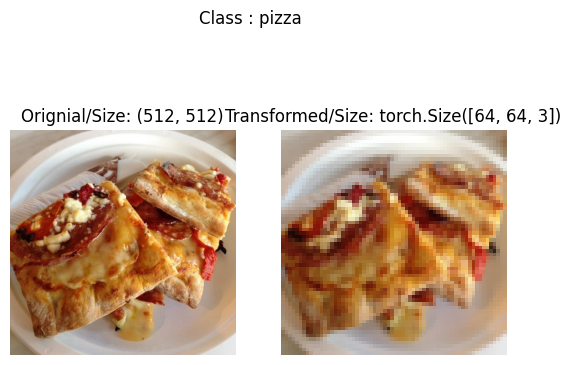

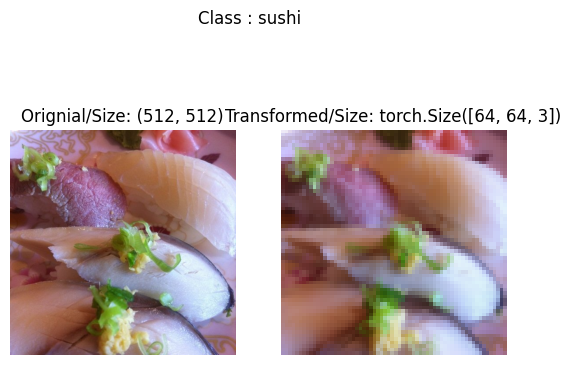

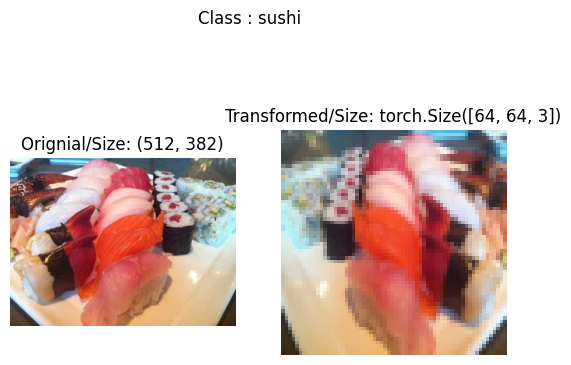

In [10]:
plot_transformed_images(images_list,data_transform,3,51)

In [11]:
TrainimgFolder = datasets.ImageFolder(train_dir,data_transform,target_transform=None)
TestimgFolder = datasets.ImageFolder(test_dir,data_transform,target_transform=None)


In [12]:
TrainimgFolder.classes

['pizza', 'steak', 'sushi']

image : torch.Size([3, 64, 64]) , label: pizza


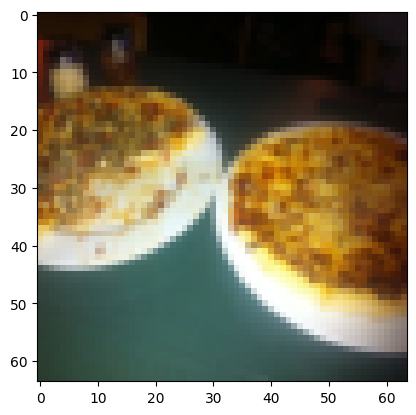

In [13]:
img ,label = TrainimgFolder[0][0],TrainimgFolder[0][1]


print(f"image : {img.shape} , label: {TrainimgFolder.classes[label]}")

plt.imshow(img.permute(1,2,0))

In [14]:
from torch.utils.data import DataLoader
import os
BATCH_SIZE=32
traindata_loader = DataLoader(dataset=TrainimgFolder,batch_size=BATCH_SIZE,num_workers=1,shuffle=True)
testdata_loader = DataLoader(dataset=TestimgFolder,batch_size=BATCH_SIZE,num_workers=1,shuffle=False)


traindata_loader,testdata_loader


(<torch.utils.data.dataloader.DataLoader at 0x1819e91e8d0>,
 <torch.utils.data.dataloader.DataLoader at 0x181c90354f0>)

In [15]:
len(traindata_loader),len(testdata_loader)

(8, 3)

In [16]:
image,label = next(iter(traindata_loader))


image.shape,label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [17]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import dataset
from torchvision import transforms
from typing import Tuple,Dict,List



TrainimgFolder.classes


['pizza', 'steak', 'sushi']

In [18]:
target_dir = train_dir
target_dir 

WindowsPath('data/pizza_steak_sushi/train')

In [19]:
class_names_found = sorted([entry.name for entry in list(os.scandir(target_dir))])
class_names_found

['pizza', 'steak', 'sushi']

In [20]:
def find_classes(dir:str) -> Tuple[List[str],Dict[str,int]]:
    classes = sorted([entry.name for entry in list(os.scandir(dir)) if entry.is_dir()])
    if not classes:
        raise FileNotFoundError("There is no class in dir path")
    
    class_to_idx = {class_name:i for i,class_name in enumerate(classes)}
    
    return classes,class_to_idx

In [21]:
find_classes(target_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [22]:
import pathlib
from PIL import Image

class Food100L(torch.utils.data.Dataset):
    def  __init__(self
                  ,target_dir:str
                  ,transform=None):
        super().__init__()
        self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes,self.class_to_idx = find_classes(target_dir)
        
    def load_image(self,index:int) -> Image.Image:
        image_path = self.paths[index]
        return  Image.open(image_path)
    
    def __len__(self) -> int:
        return len(self.paths)
    
    def __getitem__(self, index)  -> Tuple[torch.Tensor,int]:
        image= self.load_image(index)
        label=self.class_to_idx[self.paths[0].parent.name]
        return self.transform(image) if self.transform else image,label
    
    

In [23]:
Food100LDT =Food100L("data/pizza_steak_sushi/train",transform=data_transform)

In [24]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    
    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")
    
    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples 
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

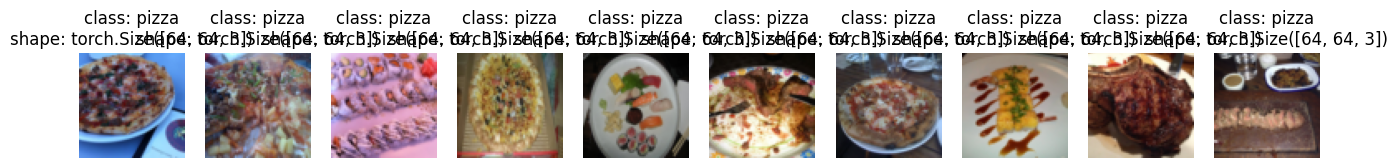

In [25]:
display_random_images(Food100LDT,Food100LDT.classes,10)

In [37]:
from torch import nn
simple_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

# 2. Turn data into DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of workers 
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create DataLoader's
train_dataloader_simple = DataLoader(train_data_simple, 
                                     batch_size=BATCH_SIZE, 
                                     shuffle=True, 
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple, 
                                    batch_size=BATCH_SIZE, 
                                    shuffle=False, 
                                    num_workers=NUM_WORKERS)

device = "cuda" if torch.cuda.is_available() else "cpu"

class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data_simple.classes)).to(device)
model_0

Creating DataLoader's with batch size 32 and 12 workers.


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [38]:
def train_step(model:nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn:nn.Module,
               optimizer:torch.optim.Optimizer):
    # Model in Train Mode
    model.train()
    
    # Setup train loss and train acc
    train_loss,train_acc=0,0
    
    #loop through data loader data batches
    for batch,(X,y) in enumerate(dataloader):

        # Send data to the target device
        X,y = X.to(device),y.to(device)
        
        #1. forward pass
        y_pred = model(X)
        
        #2. Calculate the loss
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()
        
        #3. Optimizer zero grad
        optimizer.zero_grad()
        
        #4 Loss backward
        loss.backward()
        
        #5 Optimizer step
        optimizer.step()
        
        
        #calculate accuracy metric
        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
        train_acc += (y_pred_class==y).sum().item()/len(y_pred)
     
    #Adjust metric to get avg loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    
    return train_loss,train_acc
    
    
    

In [39]:
def test_step(model:torch.nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              device=device):
    #eval mode
    model.eval()
    
    test_loss,test_acc=0,0
    #turn on infrence mode
    with torch.inference_mode():
        #Loop through Dataloader batches
        for batch,(X,y) in enumerate(dataloader):
            #send data to the target device
            X,y=X.to(device),y.to(device)
            
            #1.forward pass
            test_pred_logits = model(X)
            
            # calculate loss
            loss = loss_fn(test_pred_logits,y)
            test_loss += loss.item()
            
            test_pred_class = torch.argmax(torch.softmax(test_pred_logits,dim=1),dim=1)
            test_acc += (test_pred_class==y).sum().item()/len(test_pred_class)
    
        #Adjust metric to get avg loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    
    return test_loss,test_acc

In [42]:
torch.manual_seed(42)

from timeit import default_timer as timer

import tqdm

EPOCH_SIZE=100

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(),lr=10e-4)
for epoch in tqdm.tqdm(range(EPOCH_SIZE)):
    print(f"Epoch: {epoch} \n ---------------------")
    train_step(model_0,
               train_dataloader_simple,
               loss_fn=loss_fn,
               optimizer=optimizer)
    if(epoch % 10 == 0):
        test_step(model_0,
               test_dataloader_simple,
               loss_fn=loss_fn
               )




  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 
 ---------------------


  1%|          | 1/100 [00:14<23:12, 14.06s/it]

Epoch: 1 
 ---------------------


  2%|▏         | 2/100 [00:21<16:20, 10.00s/it]

...

Epoch: 19 
 ---------------------


 20%|██        | 20/100 [02:35<09:29,  7.11s/it]

Epoch: 20 
 ---------------------


 20%|██        | 20/100 [02:48<11:15,  8.44s/it]


KeyboardInterrupt: 

In [43]:
test_step(model_0,
               test_dataloader_simple,
               loss_fn=loss_fn
               )


(1.0146162311236064, 0.5464015151515151)